<a href="https://colab.research.google.com/github/shr-coder/Analytics3/blob/main/08_Animal_Classification_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Animal Classification

In [ ]:
# TODO: Download datasets

!wget https://storage.googleapis.com/adsa-data/animal-classification/animal.zip
!unzip -q animal.zip -d temp


--2026-05-08 18:54:37--  https://storage.googleapis.com/adsa-data/animal-classification/animal.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.24.207, 172.217.194.207, 172.217.70.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.24.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 570445498 (544M) [application/zip]
Saving to: ‘animal.zip’

animal.zip          100%[===================>] 544.02M  11.1MB/s    in 51s     

2026-05-08 18:55:30 (10.6 MB/s) - ‘animal.zip’ saved [570445498/570445498]



In [ ]:
!mkdir -p data/dog
!mkdir -p data/cat
!cp temp/train/dog.* data/dog/
!cp temp/train/cat.* data/cat/

In [ ]:
import os

dog_count = len(os.listdir("./data/dog"))
cat_count = len(os.listdir("./data/cat"))
print("Dog pictures: ", dog_count)
print("Cat pictures: ", cat_count)


Dog pictures:  12500
Cat pictures:  12500


## Data Preparation

In [ ]:
IMAGE_WIDTH=150
IMAGE_HEIGHT=150
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)
batch_size=32

In [ ]:
# TODO: Split and load datasets

import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds

train_ds = tf.keras.utils.image_dataset_from_directory(
  'data',
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=IMAGE_SIZE,
  batch_size=batch_size)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  'data',
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=IMAGE_SIZE,
  batch_size=batch_size)


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['cat', 'dog']


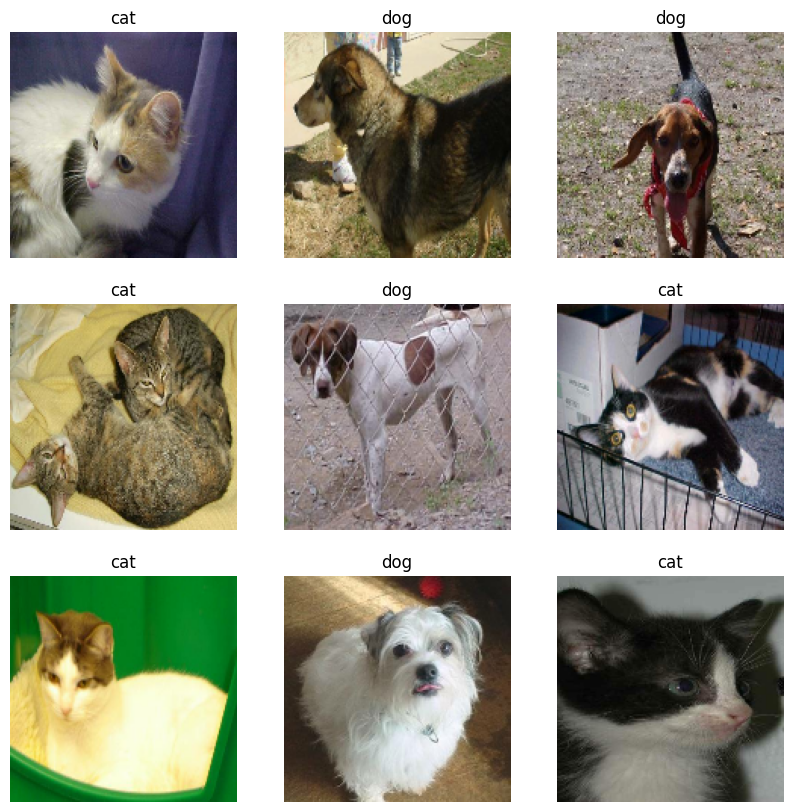

In [ ]:
# TODO: Plot some images along with their labels
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in val_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")


In [ ]:
# TODO: Set cache for datasets
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Model Preparation

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.losses import SparseCategoricalCrossentropy

model = tf.keras.models.Sequential()

# TODO: Load EfficientNetB7 model with pretrained weights
# but without the fully-connected layer at the top.
# We want to add our own FC layers and outputs
base = tf.keras.applications.EfficientNetB7(
    include_top=False,
    input_shape=IMAGE_SIZE + (3,)
)
model.add(base)

# TODO: Add a GlobalAveragePooling2D layer
model.add(tf.keras.layers.GlobalAveragePooling2D())

# TODO: Add a Dropout layer
model.add(tf.keras.layers.Dropout(0.5))

# TODO: Add outputs
model.add(tf.keras.layers.Dense(units=2, activation='softmax'))

# Allow model's weights to be updated
model.trainable = True

# TODO: Freeze base layers (Don't allow weights of the base to be updated)
base.trainable = False

for layer in model.layers:
    print(layer.name, ' ', layer.trainable)

# TODO: Add the loss function based on your outputs
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
efficientnetb7   False
global_average_pooling2d   True
dropout   True
dense   True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb7 (Functional)     │ (None, 5, 5, 2560)     │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2560)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         5,122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,102,809 (244.53 MB)

 Trainable params: 5,122 (20.01 KB)

 Non-trainable params: 64,097,687 (244.51 MB)

## Training

In [ ]:
# TODO: Train model for 1 epoch
epochs = 1

train = model.fit(
    train_ds,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=val_ds
)


625/625 ━━━━━━━━━━━━━━━━━━━━ 245s 253ms/step - accuracy: 0.9664 - loss: 0.0923 - val_accuracy: 0.9784 - val_loss: 0.0621


## Testing

In [ ]:
# TODO: Load test set
!wget https://storage.googleapis.com/adsa-data/animal-classification/test.zip
!unzip test.zip

--2026-05-08 19:00:14--  https://storage.googleapis.com/adsa-data/animal-classification/test.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.10.207, 142.251.12.207, 142.250.4.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.10.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 370194 (362K) [application/zip]
Saving to: ‘test.zip’

test.zip            100%[===================>] 361.52K   266KB/s    in 1.4s    

2026-05-08 19:00:18 (266 KB/s) - ‘test.zip’ saved [370194/370194]

Archive:  test.zip
   creating: test/
  inflating: test/cat1.jpg           
  inflating: test/cat2.jpg           
  inflating: test/cat3.jpg           
  inflating: test/dog1.jpg           
  inflating: test/dog2.jpg           
  inflating: test/dog3.jpg           


1/1 ━━━━━━━━━━━━━━━━━━━━ 1261s 1261s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


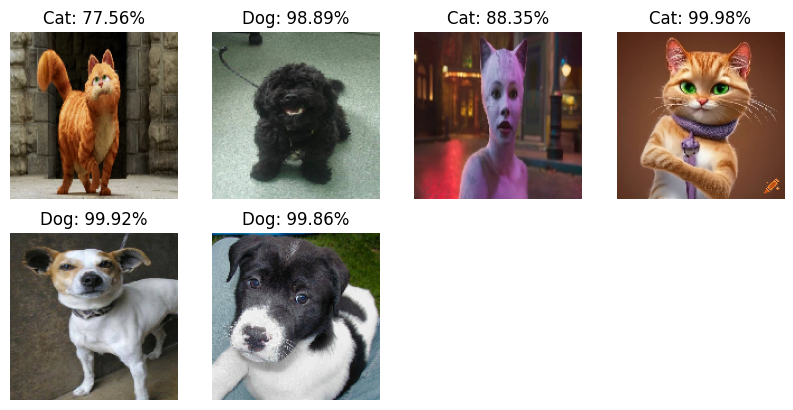

In [ ]:
# TODO: Retry again with downloaded images

import glob
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

plt.figure(figsize=(10, 10))
for i, file in enumerate(glob.glob('test/*')):
    img = load_img(file, target_size=IMAGE_SIZE)

    # convert to array
    img = img_to_array(img)
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(img.astype("uint8"))

    # reshape into a single sample with 3 channels
    img = img.reshape(1, IMAGE_WIDTH, IMAGE_HEIGHT, 3)
    predict = model.predict(img)
    percent = predict[0][0]*100

    result = 'Cat'
    if percent < 50:
        result = 'Dog'
        percent = 100 - percent

    plt.title(result + ": " + str(round(percent, 2)) + "%")
    plt.axis("off")
